# Exploratory Data Analysis

This notebook explores the S&P 500 return and volatility data to motivate the modelling choices made in this project.

**Key questions answered here:**
1. What do S&P 500 log returns look like? Are they normally distributed?
2. Is there volatility clustering — the stylized fact that motivates GARCH?
3. Are squared returns autocorrelated? (A pre-condition for GARCH to be useful.)
4. What does realized volatility look like over time — and what regimes stand out?

In [1]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

from data_loader import load_dataset
from features import build_feature_matrix, TARGET_COL
colors = ['#5B82AD','#D0A52A', '#2A958E', '#966BB5', '#B85C5C', '#7A7A7A', '#333333']

## 1. Load data

In [2]:
raw = load_dataset(vol_window=5)
feature_df = build_feature_matrix(raw).dropna(subset=[TARGET_COL])

returns = raw['log_return'].dropna()
realized_vol = feature_df[TARGET_COL]

print(f"Date range : {raw.index[0].date()} → {raw.index[-1].date()}")
print(f"Trading days: {len(raw)}")
print(f"Feature matrix rows: {len(feature_df)}")
raw[['Close', 'log_return', 'realized_vol_lag1']].tail()

Date range : 2005-01-04 → 2026-08-05
Trading days: 5430
Feature matrix rows: 5404


/Users/klevy/Documents/volatility_forecasting/notebooks/../src/data_loader.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")


,Close,log_return,realized_vol_lag1
Price,,,
2026-07-30,7437.629883,0.016468,0.178573
2026-07-31,7489.720215,0.006979,0.183757
2026-08-03,7600.500000,0.014683,0.202167
2026-08-04,7736.520020,0.017738,0.217950
2026-08-05,7723.549805,-0.001678,0.129361


## 2. S&P 500 price and log returns

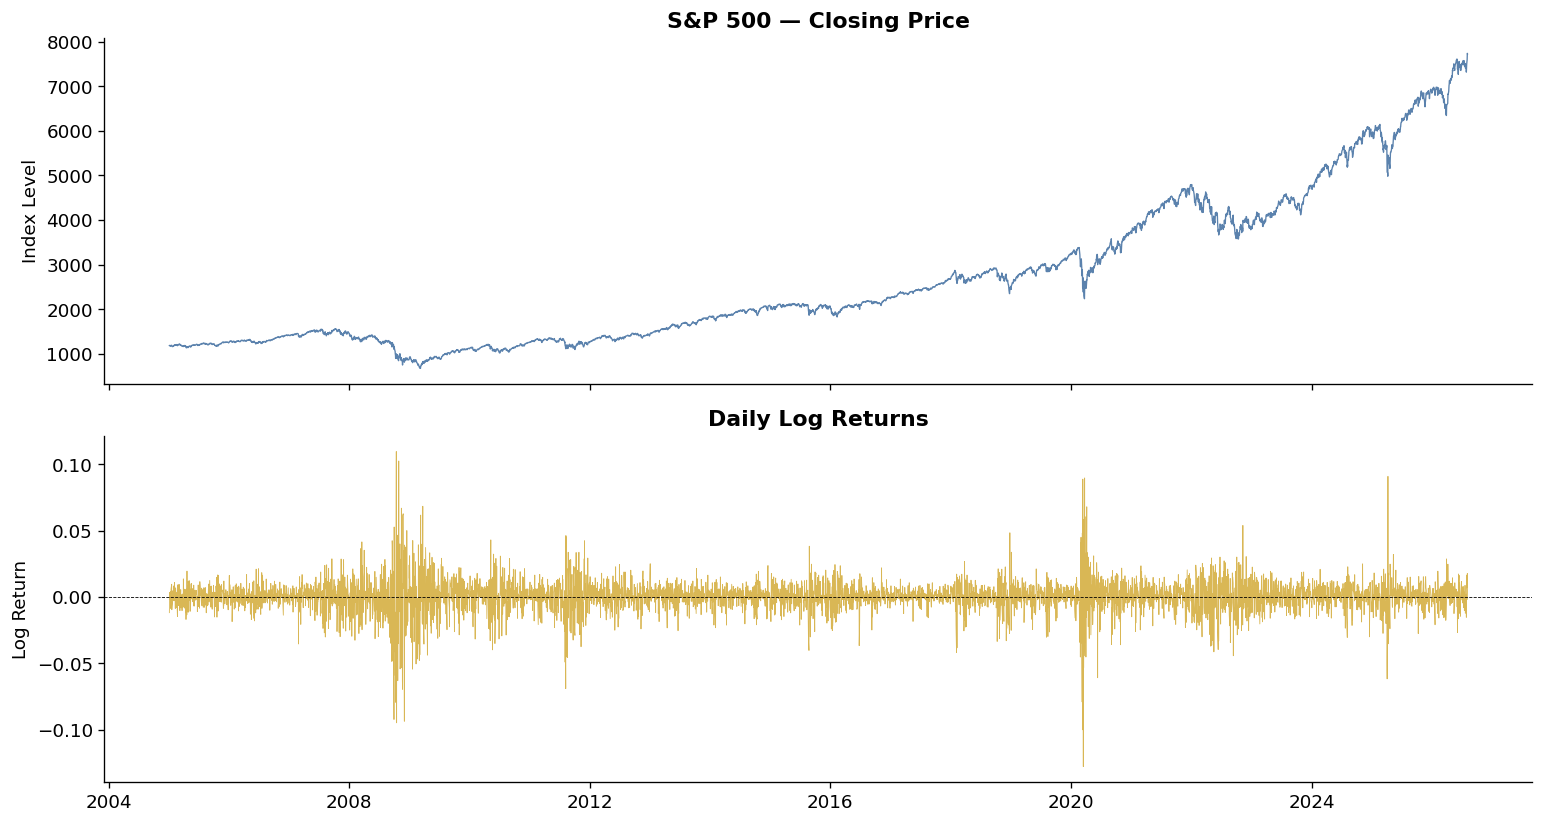

Mean daily return : 0.00034
Std daily return  : 0.01201
Min               : -0.1277 (worst day)
Max               : 0.1096 (best day)


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(raw['Close'], color=colors[0], linewidth=0.8)
axes[0].set_title('S&P 500 — Closing Price', fontweight='bold')
axes[0].set_ylabel('Index Level')

axes[1].plot(returns, color=colors[1], linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title('Daily Log Returns', fontweight='bold')
axes[1].set_ylabel('Log Return')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print(f"Mean daily return : {returns.mean():.5f}")
print(f"Std daily return  : {returns.std():.5f}")
print(f"Min               : {returns.min():.4f} (worst day)")
print(f"Max               : {returns.max():.4f} (best day)")

## 3. Return distribution

Financial returns are well-known to have **fat tails** (excess kurtosis) as extreme events happen more often than a normal distribution would predict. This matters for model choice.

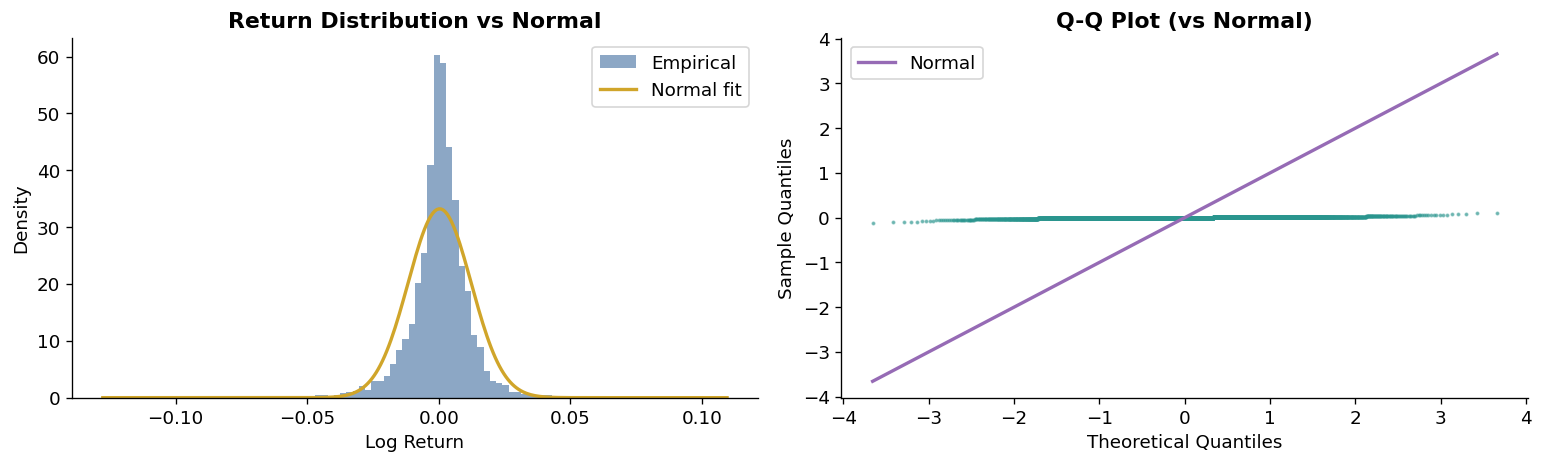

Excess kurtosis (0 = Gaussian): 13.211
Jarque-Bera p-value           : 0.00e+00  (reject normality)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram vs normal
ax = axes[0]
ax.hist(returns, bins=100, density=True, color=colors[0], alpha=0.7, label='Empirical')
x = np.linspace(returns.min(), returns.max(), 300)
ax.plot(x, stats.norm.pdf(x, returns.mean(), returns.std()),
        color=colors[1], linewidth=2, label='Normal fit')
ax.set_title('Return Distribution vs Normal', fontweight='bold')
ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
ax.legend()

# QQ plot
ax = axes[1]
theoretical_q, sample_q = stats.probplot(returns, dist='norm')[0]
ax.scatter(theoretical_q, sample_q, s=2, color=colors[2], alpha=0.5)
ax.plot(theoretical_q, theoretical_q, color=colors[3], linewidth=2, label='Normal')
ax.set_title('Q-Q Plot (vs Normal)', fontweight='bold')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.legend()

plt.tight_layout()
plt.show()

kurt = stats.kurtosis(returns)
_, jb_p = stats.jarque_bera(returns)
print(f"Excess kurtosis (0 = Gaussian): {kurt:.3f}")
print(f"Jarque-Bera p-value           : {jb_p:.2e}  ({'reject normality' if jb_p < 0.05 else 'fail to reject'})")

## 4. Volatility clustering

Volatility clustering is the defining stylized fact of financial returns: large moves tend to be followed by large moves, and calm periods tend to persist. This is the key empirical motivation for GARCH models and it's visible with the naked eye.

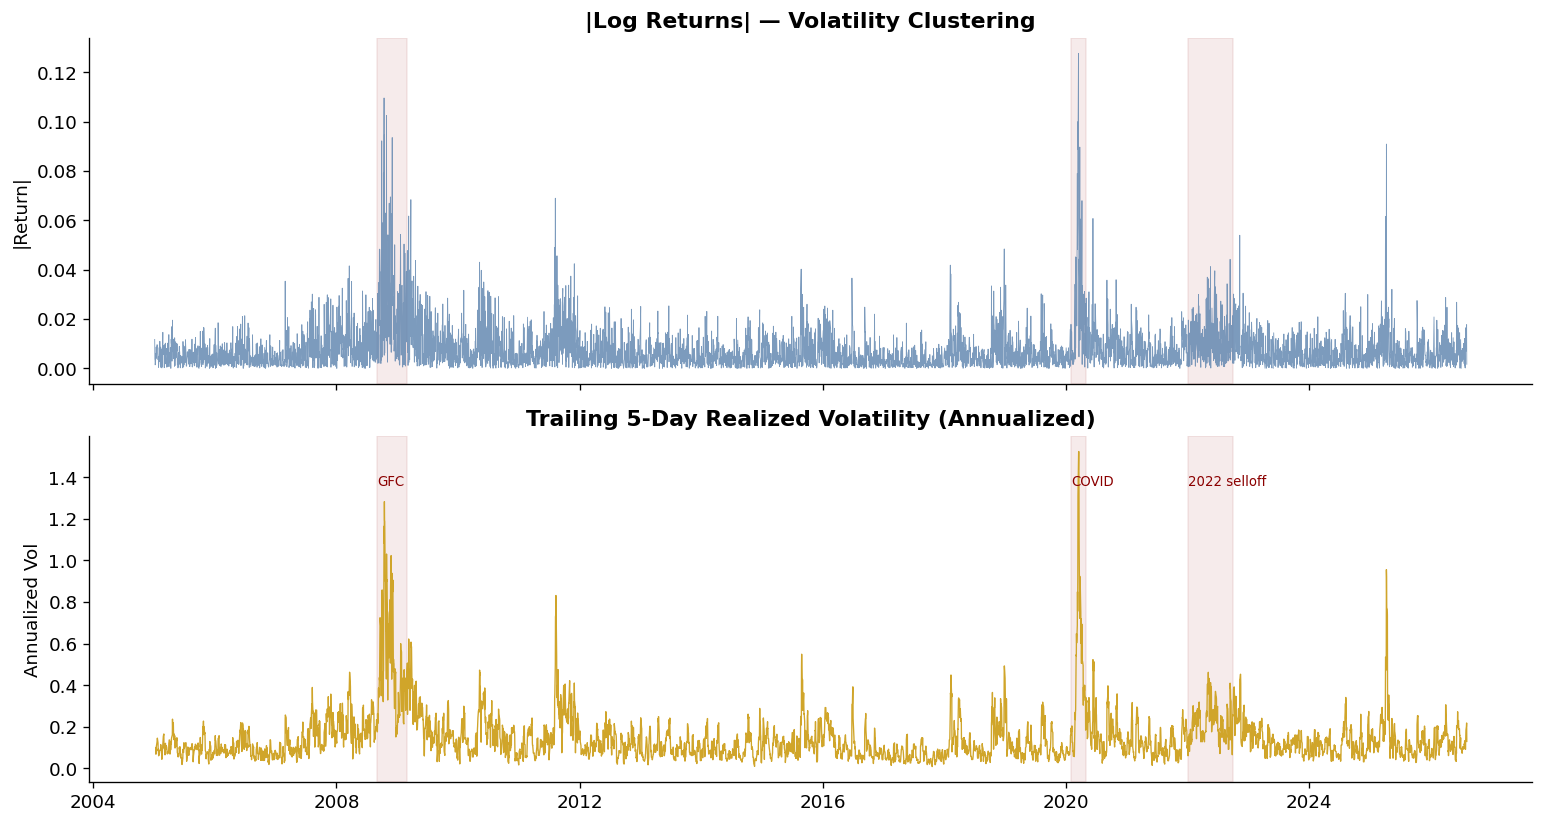

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Absolute returns (proxy for volatility)
axes[0].plot(returns.abs(), color=colors[0], linewidth=0.5, alpha=0.8)
axes[0].set_title('|Log Returns| — Volatility Clustering', fontweight='bold')
axes[0].set_ylabel('|Return|')

# Rolling realized volatility
axes[1].plot(raw['realized_vol_lag1'].dropna(), color=colors[1], linewidth=0.8)
axes[1].set_title('Trailing 5-Day Realized Volatility (Annualized)', fontweight='bold')
axes[1].set_ylabel('Annualized Vol')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Annotate crisis periods
crises = [
    ('2008-09', '2009-03', 'GFC'),
    ('2020-02', '2020-05', 'COVID'),
    ('2022-01', '2022-10', '2022 selloff'),
]
for start, end, label in crises:
    for ax in axes:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.12, color=colors[4])
    axes[1].text(pd.Timestamp(start), axes[1].get_ylim()[1] * 0.85,
                 label, fontsize=8, color='darkred')

plt.tight_layout()
plt.show()

## 5. Autocorrelation of squared returns

If squared returns are autocorrelated, past volatility is informative about future volatility — which is the formal statistical basis for why GARCH and our ML/DL models might work at all.

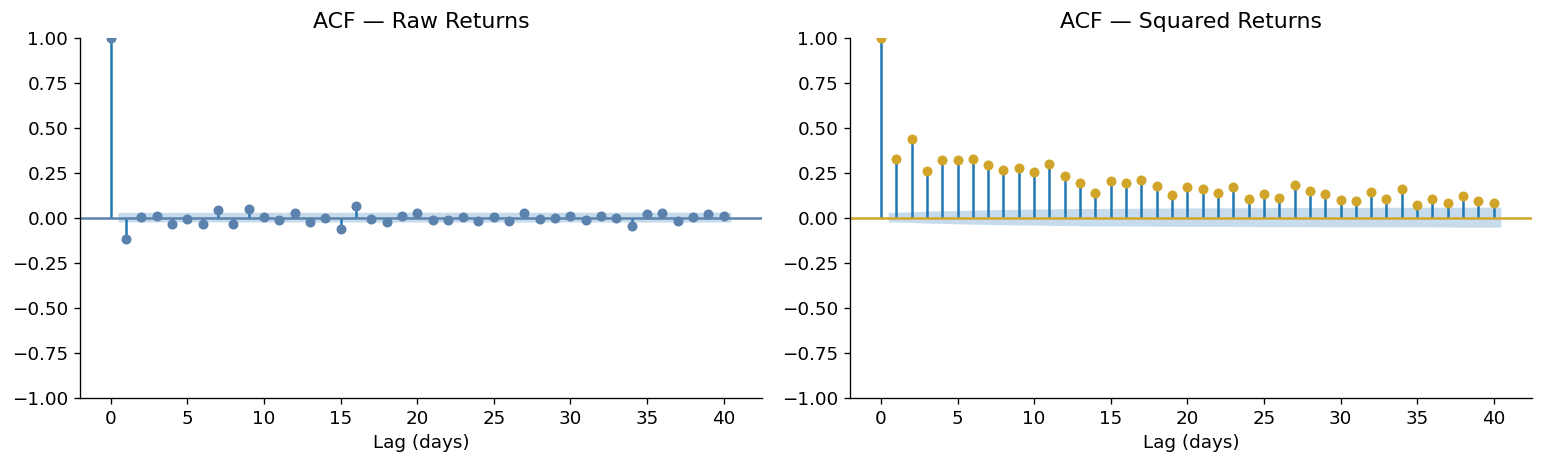

Raw returns: little autocorrelation (markets are mostly efficient)
Squared returns: significant autocorrelation → volatility is predictable
This justifies GARCH and the ML/DL approach taken in this project.


In [6]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_acf(returns, lags=40, ax=axes[0], title='ACF — Raw Returns', color=colors[0])
plot_acf(returns**2, lags=40, ax=axes[1], title='ACF — Squared Returns', color=colors[1])

axes[0].set_xlabel('Lag (days)')
axes[1].set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()

print("Raw returns: little autocorrelation (markets are mostly efficient)")
print("Squared returns: significant autocorrelation → volatility is predictable")
print("This justifies GARCH and the ML/DL approach taken in this project.")

## 6. Realized volatility distribution and regimes

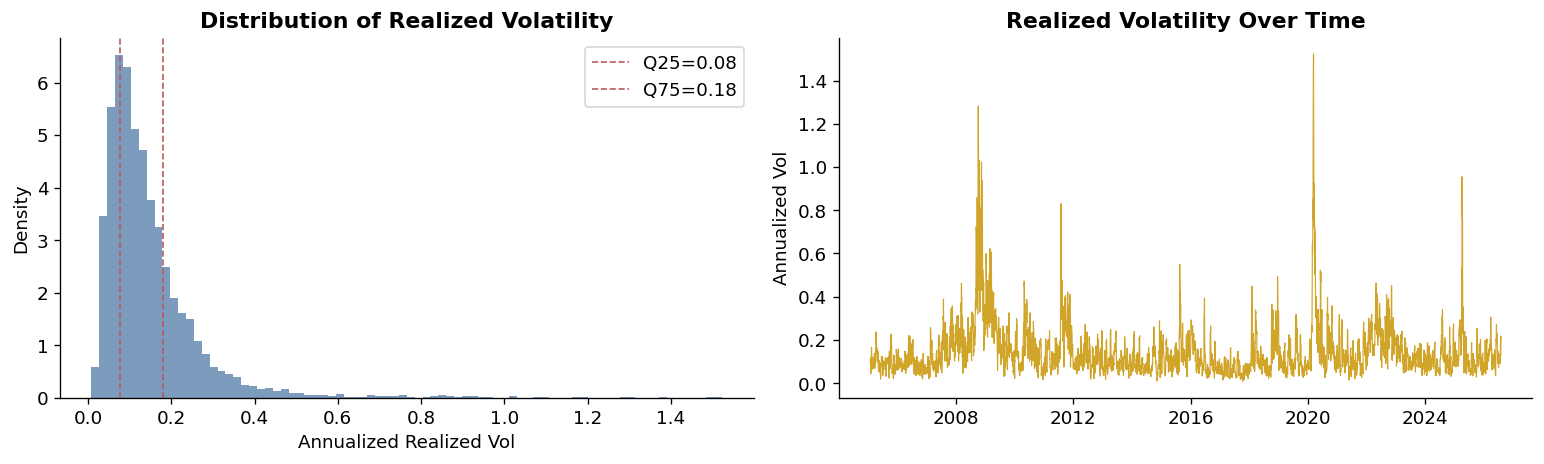

Mean realized vol : 0.149 (14.9%)
Std realized vol  : 0.126
Max realized vol  : 1.523 (on 2020-03-11)
Min realized vol  : 0.008 (on 2017-10-12)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of realized vol
axes[0].hist(realized_vol.dropna(), bins=80, color=colors[0], alpha=0.8, density=True)
axes[0].set_title('Distribution of Realized Volatility', fontweight='bold')
axes[0].set_xlabel('Annualized Realized Vol')
axes[0].set_ylabel('Density')

low = realized_vol.quantile(0.25)
high = realized_vol.quantile(0.75)
axes[0].axvline(low, color=colors[4], linestyle='--', linewidth=1, label=f'Q25={low:.2f}')
axes[0].axvline(high, color=colors[4], linestyle='--', linewidth=1, label=f'Q75={high:.2f}')
axes[0].legend()

# Realized vol over time
axes[1].plot(realized_vol, color=colors[1], linewidth=0.7)
axes[1].set_title('Realized Volatility Over Time', fontweight='bold')
axes[1].set_ylabel('Annualized Vol')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print(f"Mean realized vol : {realized_vol.mean():.3f} ({realized_vol.mean()*100:.1f}%)")
print(f"Std realized vol  : {realized_vol.std():.3f}")
print(f"Max realized vol  : {realized_vol.max():.3f} (on {realized_vol.idxmax().date()})")
print(f"Min realized vol  : {realized_vol.min():.3f} (on {realized_vol.idxmin().date()})")

## 7. Feature correlation heatmap

Check whether the engineered features (lagged returns, rolling stats) are highly collinear — high collinearity doesn't hurt tree-based models like XGBoost, but is good to know about.

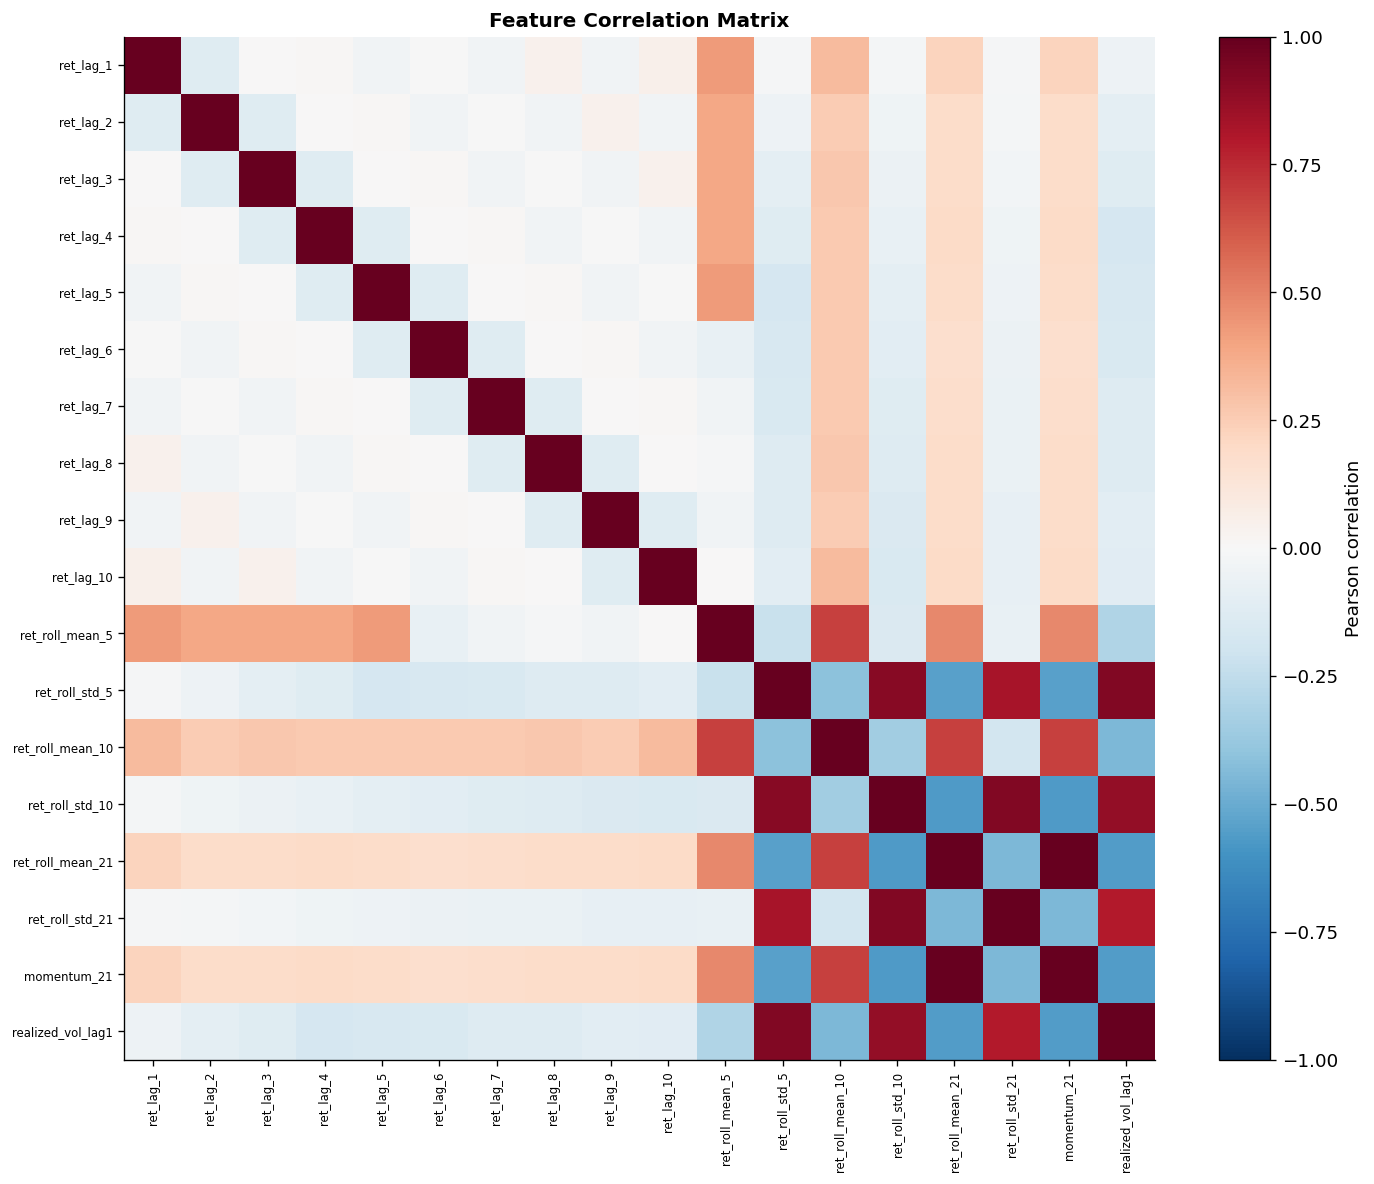

In [8]:
from features import get_feature_names

feature_cols = get_feature_names(feature_df)
corr = feature_df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=7)
ax.set_yticklabels(feature_cols, fontsize=7)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## Summary

Key takeaways from the EDA that motivate the modelling choices:

1. **Returns are not Gaussian**: fat tails confirmed by excess kurtosis and Jarque-Bera test. This is why GARCH with a Normal distribution is an imperfect baseline, and why more flexible models might help.
2. **Volatility clustering is clearly visible**: calm and turbulent regimes persist. This is the core stylized fact motivating GARCH.
3. **Squared returns are autocorrelated**: confirming that past volatility is statistically informative about future volatility, justifying all four models in this comparison.
4. **Crisis periods dominate the distribution**: GFC, COVID, 2022 selloff produce extreme volatility readings; models trained on calmer periods may fail in crises, which is something to watch for in the walk-forward evaluation.

→ See `02_results_analysis.ipynb` for model comparison results.